# Exploratory Data Analysis (EDA) of CAISO/WEIM LMP Nodes

This notebook loads the generated LMP Shapefile, inspects its attributes, and generates summary statistics and visualizations of the node distribution across balancing areas and node types.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx
from pathlib import Path

## 1. Load the Shapefile
We load the shapefile created by our script into a GeoDataFrame.

In [2]:
shp_path = Path("LMP/caiso_lmp.shp")
gdf = gpd.read_file(shp_path)

# Display first few rows
gdf.head()

,AREA,NODE_ID,TYPE,geometry
0,CA,0096WD_7_N001,GEN,POINT (-119.1312 35.44004)
1,CA,0096WD_7_N002,LOAD,POINT (-119.13132 35.44004)
2,PACE,106THSO_LNODED1,LOAD,POINT (-111.90056 40.55616)
3,PACE,118THSO_LNODER1,LOAD,POINT (-111.89667 40.53944)
4,PACE,126THSO_LNODE_LDT1,LOAD,POINT (-111.9005 40.55608)


## 2. Basic Data Documentation
Let's look at some basic descriptive statistics for our dataset. First, we'll check the number of rows and CRS. 

In [3]:
print(f"Total Number of Nodes: {len(gdf):,}")
print(f"Coordinate Reference System (CRS): {gdf.crs}")

Total Number of Nodes: 14,417
Coordinate Reference System (CRS): EPSG:4326


### Node Types Distribution
Locational Marginal Pricing (LMP) nodes represent different components of the grid, such as generation resources (`GEN`) and load (`LOAD`). Let's check the number of nodes in each category.

In [4]:
type_counts = gdf['TYPE'].value_counts()
type_df = pd.DataFrame({'Count': type_counts, 'Percentage': (type_counts / len(gdf) * 100).round(2)})
print("Node Type Distribution:")
display(type_df)

Node Type Distribution:


,Count,Percentage
TYPE,,
LOAD,10649,73.86
GEN,3768,26.14


### Balancing Authority / Control Areas
The nodes span the California ISO (CAISO) balancing area and partner areas in the Western Energy Imbalance Market (WEIM). Let's look at the distribution of nodes across these areas.

In [5]:
area_counts = gdf['AREA'].value_counts()
area_df = pd.DataFrame({'Count': area_counts, 'Percentage': (area_counts / len(gdf) * 100).round(2)})
print("Top Balancing Areas by Node Count:")
display(area_df.head(15))

Top Balancing Areas by Node Count:


,Count,Percentage
AREA,,
CA,4128,28.63
APS,1524,10.57
BPAT,1176,8.16
PACE,832,5.77
NV,813,5.64
SRP,724,5.02
NWMT,522,3.62
IPCO,497,3.45
PACW,475,3.29


## 3. Visualizing Node Locations
Let's plot the spatial distribution of the nodes. Since we are adding web map tiles as a basemap, we reproject the data to Web Mercator (`EPSG:3857`) for proper overlay alignment. 

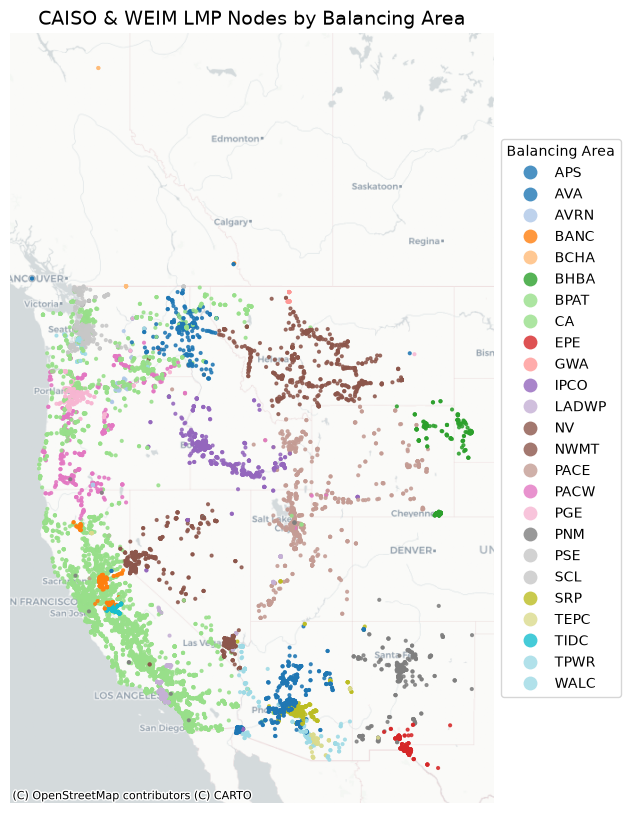

In [6]:
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))
gdf_web.plot(ax=ax, column='AREA', legend=True, markersize=4, alpha=0.8, cmap='tab20', 
             legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.5), 'title': 'Balancing Area'}, zorder=2)

# Add a light minimal basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zorder=1)

ax.set_title("CAISO & WEIM LMP Nodes by Balancing Area", fontsize=14)
ax.set_axis_off()
plt.show()